IMPORT LIBRARIES

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

In [142]:
!pip install lightgbm

In [143]:
!pip install xgboost

In [144]:
train.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_5000-9999,company_size_<10,company_size_Oct-49,company_size_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.920,21.0,1.0,36,1,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


LOAD DATASET

In [145]:
train = pd.read_csv("ERP 1.csv")
test = pd.read_csv("ERP 01.csv")

BASIC INFO

In [146]:
train.shape

(19158, 14)

In [147]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1), int64(3), object(10)
me

In [148]:
train.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


CHECK MISSING VALUES

In [149]:
train.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

DATA CLEANING

FILL MISSING VALUES

In [150]:
cols = ['gender', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type']

for cols in cols:
    train[cols].fillna('Unknown', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3588\1221923121.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[cols].fillna('Unknown', inplace=True)


In [151]:
train['experience'] = train['experience'].replace({'>20': 21, '<1': 0})
train['experience'] = train['experience'].astype(float)

In [152]:
train['last_new_job'] = train['last_new_job'].replace({'never': 0, '>4': 5})
train['last_new_job'] = train['last_new_job'].astype(float)

In [153]:
train.drop('enrollee_id', axis=1, inplace=True)

EDA

TARGET DISTRIBUTION

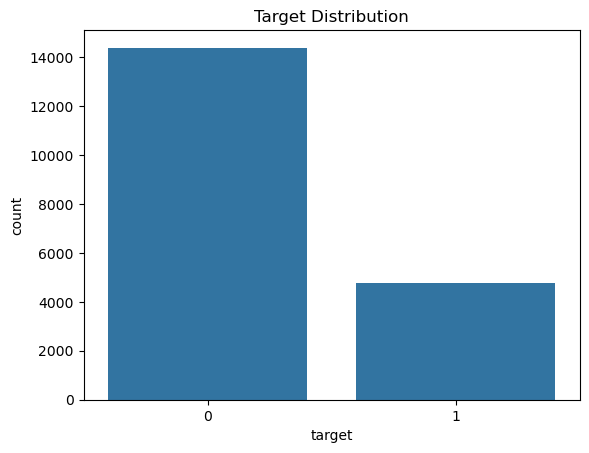

In [154]:
sns.countplot(x='target', data=train)
plt.title("Target Distribution")
plt.show()


GENDER vs TARGET

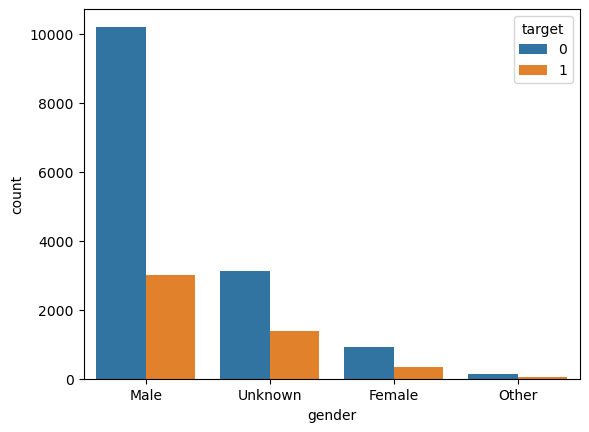

In [155]:
sns.countplot(x='gender', hue='target', data=train)
plt.show()

EXPERIENCE vs TARGET

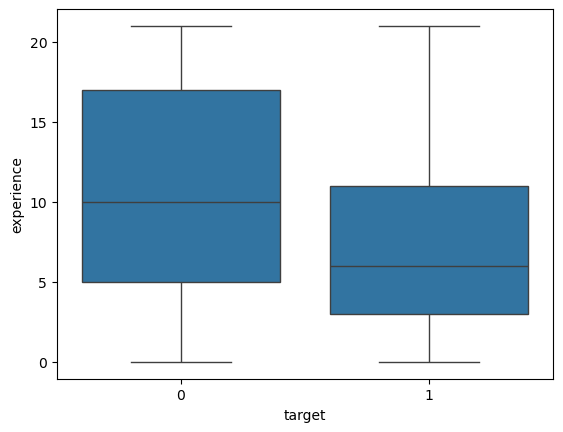

In [156]:
sns.boxplot(x='target', y='experience', data=train)
plt.show()

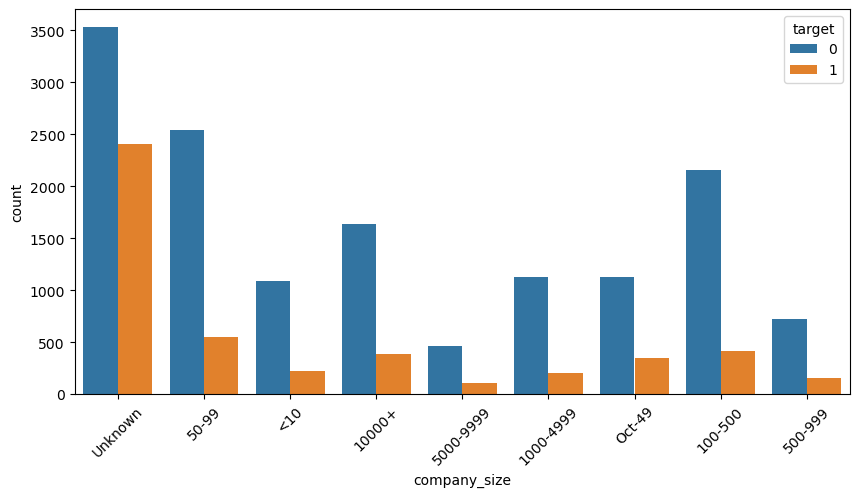

In [157]:
plt.figure(figsize=(10,5))
sns.countplot(x='company_size', hue='target', data=train)
plt.xticks(rotation=45)
plt.show()


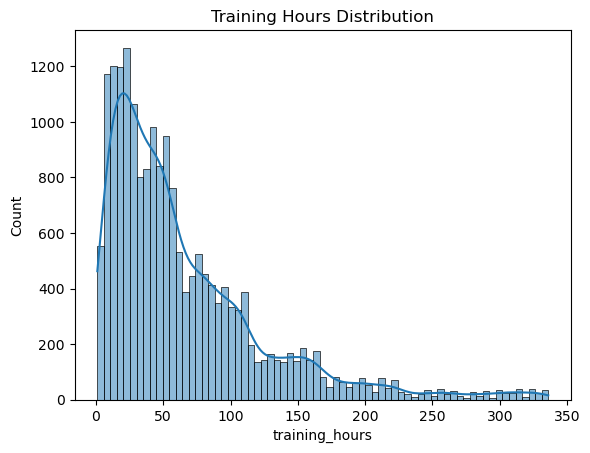

In [158]:
sns.histplot(train['training_hours'], kde=True)
plt.title("Training Hours Distribution")
plt.show()

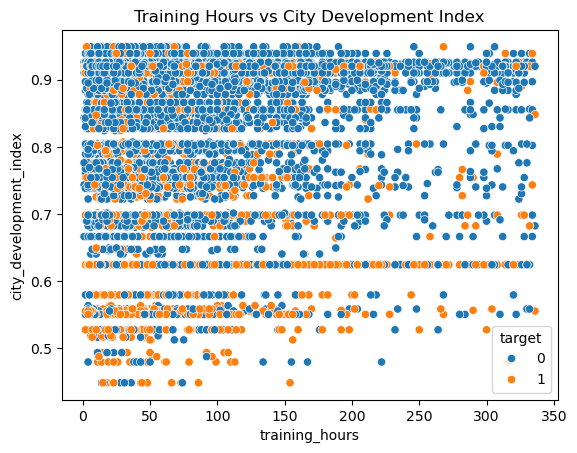

In [159]:
sns.scatterplot(x='training_hours', y='city_development_index', hue='target', data=train)
plt.title("Training Hours vs City Development Index")
plt.show()

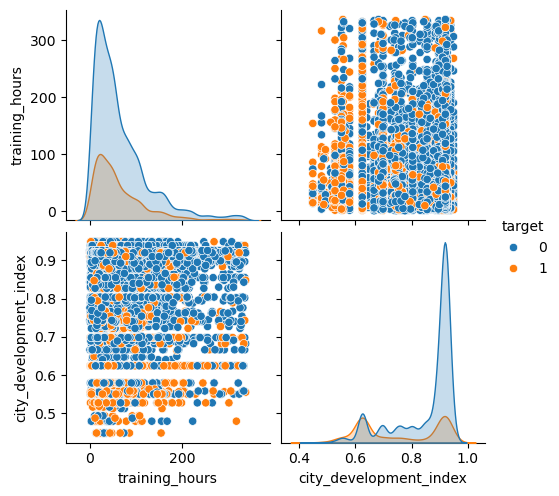

In [160]:
sns.pairplot(train[['training_hours', 'city_development_index', 'target']], hue='target')
plt.show()

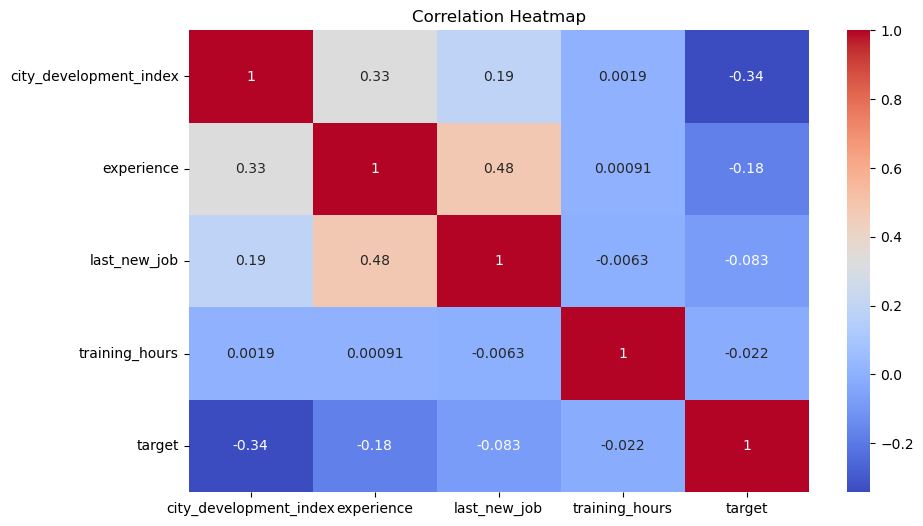

In [180]:
plt.figure(figsize=(10,6))
sns.heatmap(train.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

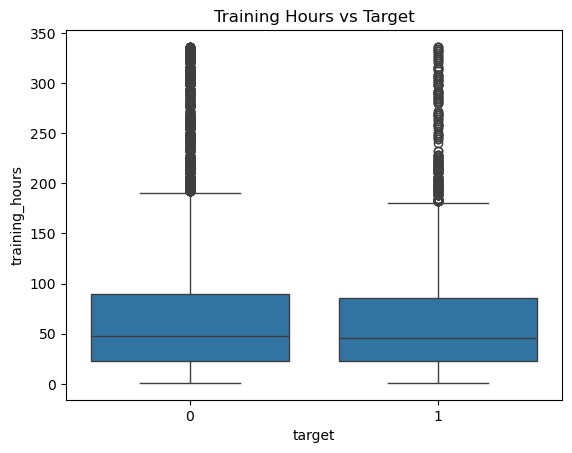

In [179]:
sns.boxplot(x='target', y='training_hours', data=train)
plt.title("Training Hours vs Target")
plt.show()

In [ ]:
print(X.isnull().sum())

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].fillna('Unknown')

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = x[num_cols].fillna(X[num_cols].median())
                           

In [ ]:
print(X.isnull().sum().sum())

ENCODING

In [ ]:
train = pd.get_dummies(train, drop_first=True)


SPLIT DATA

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.isnull().sum())

FIX MISSING VALUES IN TRAIN AND TEST

In [ ]:
#FILL CATEGORICAL COLUMNS
cat_cols = X_train.select_dtypes(include='object').columns

X_train[cat_cols] = X_train[cat_cols].fillna('Unknown')
X_test[cat_cols] = X_test[cat_cols].fillna('Unknown')

#FILL NUMERICAL COLUMNS
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

In [ ]:
print(X_train.isnull().sum().sum())

HANDLE IMBALANCE (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

TRAIN_TEST_SPLIT

In [162]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

FEATURE SCALING

In [163]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [164]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

In [165]:
X.columns = X.columns.str.replace(r'[\[\]<>]', '', regex=True)

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Xgb = XGBClassifier(eval_metric='logloss')
Xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

TRAIN ALL MODELS

In [167]:
# Logistic Regression
lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# XGBoost
Xgb = XGBClassifier(eval_metric='logloss')
Xgb.fit(X_train, y_train)
Xgb_pred = Xgb.predict(X_test)

# LightGBM
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

# LightGBM (silence logs)
lgb = LGBMClassifier(verbose=-1)

EVALUATION FUNCTION

In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
def evaluate(name, y_test, y_pred):
    print(f"-----{name}-----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()


EVALUATE ALL MODELS

In [169]:
evaluate("Logistic Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, Xgb_pred)
evaluate("LightGBM", y_test, lgb_pred)

-----Logistic Regression-----
Accuracy: 0.778705636743215
Precision: 0.5843270868824532
Recall: 0.36219640971488914
F1 Score: 0.4471968709256845

-----Random Forest-----
Accuracy: 0.7792275574112735
Precision: 0.5685210312075983
Recall: 0.4424498416050686
F1 Score: 0.497624703087886

-----XGBoost-----
Accuracy: 0.7888830897703549
Precision: 0.5794930875576036
Recall: 0.5311510031678986
F1 Score: 0.5542699724517907

-----LightGBM-----
Accuracy: 0.7993215031315241
Precision: 0.5927083333333333
Recall: 0.600844772967265
F1 Score: 0.5967488201363398



MODEL COMPARISON TABLE

In [170]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, Xgb_pred), 
        accuracy_score(y_test, lgb_pred)]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
3,LightGBM,0.799322
2,XGBoost,0.788883
1,Random Forest,0.779228
0,Logistic Regression,0.778706


SAVE MODELS

In [171]:
import pickle

In [172]:
pickle.dump(lr, open("logistic_model.pkl", "wb"))
pickle.dump(rf, open("random_forest_model.pkl", "wb"))
pickle.dump(Xgb, open("xgboost_model.pkl", "wb"))
pickle.dump(lgb, open("LightGBM_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [173]:
import os
print(os.listdir())

['.anaconda', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.python_history', '.streamlit', '.virtual_documents', 'anaconda3', 'apartment_rent_data (1).csv', 'AppData', 'Application Data', 'bank_data.xlsx', 'bank_transactions.csv', 'battery-report.html', 'beach.jpg', 'breast_cancer_data.csv', 'brew&co.csv', 'Contacts', 'Cookies', 'Cross Validation 1', 'customer_segmentation.csv', 'data.csv', 'Day1_stats.ipynb', 'Decision Tree - Iris Dataset.ipynb', 'Decision Tree 1', 'Documents', 'Downloads', 'Employee_Retention_prediction.ipynb', 'ERP 01.csv', 'ERP 1.csv', 'Favorites', 'Hierarchical clustering', 'Housing.csv', 'iris.csv', 'k', 'K-means Clustering 1', 'K-means clustering 2', 'K-nearest neighbor', 'LightGBM_model.pkl', 'Links', 'Local Settings', 'logistic_model.pkl', 'machine learning Linear Regression', 'Microsoft', 'Model Evaluation - Breast Cancer Dataset.ipynb', 'My Documents', 'NetHood', 'NTUS

In [174]:
import pickle

lr = pickle.load(open("logistic_model.pkl", "rb"))
rf = pickle.load(open("random_forest_model.pkl", "rb"))
Xgb = pickle.load(open("xgboost_model.pkl", "rb"))
lgb = pickle.load(open("LightGBM_model.pkl", "rb"))

scaler = pickle.load(open("scaler.pkl", "rb"))

In [175]:
import pickle

def load_models():
    lr = pickle.load(open("logistic_model.pkl", "rb"))
    rf = pickle.load(open("random_forest_model.pkl", "rb"))
    xgb = pickle.load(open("xgboost_model.pkl", "rb"))
    lgb = pickle.load(open("lightgbm_model.pkl", "rb"))
    scaler = pickle.load(open("scaler.pkl", "rb"))

    return lr, rf, xgb, lgb, scaler

In [176]:
lr, rf, xgb, lgb, scaler = load_models()